# ResNet-18 Transfer Learning trên CIFAR-10

## Mục tiêu

Notebook thực hiện hai thí nghiệm Transfer Learning với ResNet-18 pretrained trên ImageNet:

- **ResNet-18 A – FC only:** đóng băng toàn bộ backbone và chỉ huấn luyện lớp `fc`.
- **ResNet-18 B – Layer4 + FC:** fine-tuning `layer4` và lớp `fc`.

Hai thí nghiệm sử dụng chung:
- CIFAR-10
- DataLoader chung của nhóm
- Training engine chung của nhóm
- Optimizer Adam
- Learning rate = 0.001
- Batch size = 32
- 5 epochs

Mục tiêu là so sánh chiến lược chỉ huấn luyện classifier cuối với chiến lược fine-tuning thêm `layer4`.

In [23]:
from pathlib import Path
import sys
import time

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CELL 2 - IMPORT + PROJECT_ROOT
# Chạy được cả VS Code local và Google Colab
# ============================================================

def find_project_root():
    current = Path.cwd().resolve()

    # Các vị trí có thể chứa Practice_2
    candidates = [
        # VS Code / chạy notebook từ project
        current,
        current.parent,
        current.parent.parent,

        # Google Colab - repo đã clone
        Path("/content/UTH-Deep-Learning-nhom2/Practice_2"),
    ]

    for candidate in candidates:
        if (
            candidate.exists()
            and (candidate / "src").exists()
            and (candidate / "configs").exists()
        ):
            return candidate.resolve()

    raise FileNotFoundError(
        "Không tìm thấy Practice_2. "
        "Nếu đang dùng Colab, hãy kiểm tra repo đã được clone vào "
        "/content/UTH-Deep-Learning-nhom2."
    )


PROJECT_ROOT = find_project_root()

# Cho Python import được src
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# Import code dùng chung của nhóm
from src.data import DataConfig, build_dataloaders
from src.trainer import get_device, train_model
from src.models.resnet18 import (
    build_resnet18_fc_only,
    build_resnet18_layer4_fc,
    count_trainable_parameters,
)


# Dùng đúng lệnh nhóm trưởng yêu cầu
device = get_device()


print("===== PROJECT SETUP =====")
print("PROJECT_ROOT :", PROJECT_ROOT)
print("PyTorch      :", torch.__version__)
print("CUDA         :", torch.cuda.is_available())
print("Device       :", device)

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))

===== PROJECT SETUP =====
PROJECT_ROOT : /content/UTH-Deep-Learning-nhom2/Practice_2
PyTorch      : 2.11.0+cu128
CUDA         : True
Device       : cuda
GPU          : Tesla T4


## 3. DataLoader dùng chung

Sử dụng pipeline dữ liệu chung của nhóm từ `src.data`.

Dataset được đọc trực tiếp từ:

`Practice_2/data/raw`

Không tạo lại dataset hoặc tự chia dữ liệu trong notebook này.

In [13]:
# ============================================================
# CELL 3 - SHARED DATALOADERS
# ============================================================

# Đường dẫn dữ liệu dùng chung của nhóm
data_dir = PROJECT_ROOT / "data" / "raw"

# Cấu hình dữ liệu
data_config = DataConfig(
    data_dir=data_dir,
    image_size=224,
    batch_size=32,
    val_ratio=0.10,
    num_workers=0,
    seed=42
)

# build_dataloaders() trả về một dictionary
data_bundle = build_dataloaders(data_config)

# Lấy các DataLoader và thông tin cần thiết từ dictionary
train_loader = data_bundle["train_loader"]
val_loader = data_bundle["val_loader"]
test_loader = data_bundle["test_loader"]
class_names = data_bundle["class_names"]

train_dataset = data_bundle["train_dataset"]
val_dataset = data_bundle["val_dataset"]
test_dataset = data_bundle["test_dataset"]

print("===== DATALOADER READY =====")
print("Data directory :", data_dir)
print("Train samples  :", len(train_dataset))
print("Val samples    :", len(val_dataset))
print("Test samples   :", len(test_dataset))
print("Train batches  :", len(train_loader))
print("Val batches    :", len(val_loader))
print("Test batches   :", len(test_loader))
print("Classes        :", class_names)
print("Number classes :", len(class_names))

===== DATALOADER READY =====
Data directory : /content/UTH-Deep-Learning-nhom2/Practice_2/data/raw
Train samples  : 45000
Val samples    : 5000
Test samples   : 10000
Train batches  : 1407
Val batches    : 157
Test batches   : 313
Classes        : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number classes : 10


## 4. Xây dựng ResNet-18 A và ResNet-18 B

- **ResNet-18 A:** chỉ huấn luyện lớp `fc`.
- **ResNet-18 B:** fine-tuning `layer4` và `fc`.

Cả hai mô hình sử dụng ResNet-18 pretrained trên ImageNet và thay lớp phân loại cuối để phù hợp với 10 lớp CIFAR-10.

In [14]:
# ============================================================
# CELL 4 - BUILD RESNET-18 A AND B
# ============================================================

NUM_CLASSES = len(class_names)

model_a = build_resnet18_fc_only(
    num_classes=NUM_CLASSES
)

model_b = build_resnet18_layer4_fc(
    num_classes=NUM_CLASSES
)

print("===== RESNET-18 MODELS CREATED =====")
print("Number of classes :", NUM_CLASSES)

print("\nResNet-18 A")
print("Strategy           : FC only")
print("Final FC layer     :", model_a.fc)

print("\nResNet-18 B")
print("Strategy           : Layer4 + FC")
print("Final FC layer     :", model_b.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 242MB/s]


===== RESNET-18 MODELS CREATED =====
Number of classes : 10

ResNet-18 A
Strategy           : FC only
Final FC layer     : Linear(in_features=512, out_features=10, bias=True)

ResNet-18 B
Strategy           : Layer4 + FC
Final FC layer     : Linear(in_features=512, out_features=10, bias=True)


## 5. So sánh số tham số có thể huấn luyện

Kiểm tra số lượng tham số trainable của hai chiến lược để xác nhận việc freeze/fine-tuning được thiết lập đúng.

In [15]:
# ============================================================
# CELL 5 - TRAINABLE PARAMETERS
# ============================================================

total_a = sum(
    p.numel()
    for p in model_a.parameters()
)

total_b = sum(
    p.numel()
    for p in model_b.parameters()
)

trainable_a = count_trainable_parameters(model_a)
trainable_b = count_trainable_parameters(model_b)

frozen_a = total_a - trainable_a
frozen_b = total_b - trainable_b

print("===== PARAMETER COMPARISON =====")

print("\nResNet-18 A - FC only")
print(f"Total params     : {total_a:,}")
print(f"Trainable params : {trainable_a:,}")
print(f"Frozen params    : {frozen_a:,}")

print("\nResNet-18 B - Layer4 + FC")
print(f"Total params     : {total_b:,}")
print(f"Trainable params : {trainable_b:,}")
print(f"Frozen params    : {frozen_b:,}")

===== PARAMETER COMPARISON =====

ResNet-18 A - FC only
Total params     : 11,181,642
Trainable params : 5,130
Frozen params    : 11,176,512

ResNet-18 B - Layer4 + FC
Total params     : 11,181,642
Trainable params : 8,398,858
Frozen params    : 2,782,784


## 6. Forward-pass check

Kiểm tra một batch dữ liệu thật từ DataLoader chung để đảm bảo:

- dữ liệu được đưa lên đúng `device`,
- cả hai mô hình chạy được,
- output có đúng 10 lớp CIFAR-10.

In [16]:
# ============================================================
# CELL 6 - FORWARD PASS CHECK
# ============================================================

device = get_device()

# Lấy một batch thật từ DataLoader chung
images, labels = next(iter(train_loader))

# Đưa model lên device
model_a = model_a.to(device)
model_b = model_b.to(device)

# Đưa dữ liệu lên cùng device
images = images.to(device)
labels = labels.to(device)

# Chuyển sang evaluation mode để kiểm tra forward pass
model_a.eval()
model_b.eval()

with torch.no_grad():
    outputs_a = model_a(images)
    outputs_b = model_b(images)

print("===== FORWARD PASS CHECK =====")
print("Device         :", device)
print("Images device  :", images.device)
print("Labels device  :", labels.device)

print("\nInput shape    :", images.shape)
print("Labels shape   :", labels.shape)
print("Output A shape :", outputs_a.shape)
print("Output B shape :", outputs_b.shape)

===== FORWARD PASS CHECK =====
Device         : cuda
Images device  : cuda:0
Labels device  : cuda:0

Input shape    : torch.Size([32, 3, 224, 224])
Labels shape   : torch.Size([32])
Output A shape : torch.Size([32, 10])
Output B shape : torch.Size([32, 10])


## 7. Cấu hình training chung

Hai thí nghiệm sử dụng cùng cấu hình huấn luyện để đảm bảo so sánh công bằng:

- Loss: `CrossEntropyLoss`
- Optimizer: `Adam`
- Learning rate: `0.001`
- Batch size: `32`
- Epochs: `5`
- Device: tự động lấy từ `get_device()`

Checkpoint và TensorBoard log được lưu trong thư mục dùng chung của `Practice_2`.

In [17]:
# ============================================================
# CELL 7 - SHARED TRAINING CONFIG
# ============================================================

LEARNING_RATE = 0.001
NUM_EPOCHS = 5

# Thư mục dùng chung
checkpoint_dir = PROJECT_ROOT / "checkpoints"
runs_dir = PROJECT_ROOT / "runs"

checkpoint_dir.mkdir(parents=True, exist_ok=True)
runs_dir.mkdir(parents=True, exist_ok=True)

# Loss function dùng chung
criterion = nn.CrossEntropyLoss()

# Optimizer A - chỉ lấy các tham số trainable
optimizer_a = optim.Adam(
    filter(lambda p: p.requires_grad, model_a.parameters()),
    lr=LEARNING_RATE
)

# Optimizer B - chỉ lấy các tham số trainable
optimizer_b = optim.Adam(
    filter(lambda p: p.requires_grad, model_b.parameters()),
    lr=LEARNING_RATE
)

# Đường dẫn checkpoint
checkpoint_a = checkpoint_dir / "resnet18_fc_only_best.pth"
checkpoint_b = checkpoint_dir / "resnet18_layer4_fc_best.pth"

# TensorBoard log directory
log_dir_a = runs_dir / "resnet18_fc_only"
log_dir_b = runs_dir / "resnet18_layer4_fc"

device = get_device()

print("===== TRAINING CONFIG =====")
print("Loss          : CrossEntropyLoss")
print("Optimizer A   : Adam")
print("Optimizer B   : Adam")
print("Learning rate :", LEARNING_RATE)
print("Batch size    :", data_config.batch_size)
print("Epochs        :", NUM_EPOCHS)
print("Device        :", device)

print("\nCheckpoint A  :", checkpoint_a)
print("Checkpoint B  :", checkpoint_b)

print("\nTensorBoard A :", log_dir_a)
print("TensorBoard B :", log_dir_b)

===== TRAINING CONFIG =====
Loss          : CrossEntropyLoss
Optimizer A   : Adam
Optimizer B   : Adam
Learning rate : 0.001
Batch size    : 32
Epochs        : 5
Device        : cuda

Checkpoint A  : /content/UTH-Deep-Learning-nhom2/Practice_2/checkpoints/resnet18_fc_only_best.pth
Checkpoint B  : /content/UTH-Deep-Learning-nhom2/Practice_2/checkpoints/resnet18_layer4_fc_best.pth

TensorBoard A : /content/UTH-Deep-Learning-nhom2/Practice_2/runs/resnet18_fc_only
TensorBoard B : /content/UTH-Deep-Learning-nhom2/Practice_2/runs/resnet18_layer4_fc


In [18]:
!git clone https://github.com/tanlen06-debug/UTH-Deep-Learning-nhom2.git

Cloning into 'UTH-Deep-Learning-nhom2'...
remote: Enumerating objects: 570, done.
remote: Counting objects: 100% (245/245), done.
remote: Compressing objects: 100% (165/165), done.
remote: Total 570 (delta 137), reused 170 (delta 80), pack-reused 325 (from 1)
Receiving objects: 100% (570/570), 11.76 MiB | 18.93 MiB/s, done.
Resolving deltas: 100% (252/252), done.


## 8. Train ResNet-18 A — FC only

Huấn luyện ResNet-18 A bằng training engine chung của nhóm.

Ở chiến lược này, toàn bộ backbone được đóng băng và chỉ lớp `fc` được cập nhật trong quá trình huấn luyện.

In [24]:
# ============================================================
# CELL 8 - TRAIN RESNET-18 A
# ============================================================

print("===== TRAIN RESNET-18 A =====")
print("Strategy         : FC only")
print("Trainable params :", f"{trainable_a:,}")
print("Optimizer        : Adam")
print("Learning rate    :", LEARNING_RATE)
print("Batch size       :", data_config.batch_size)
print("Epochs           :", NUM_EPOCHS)
print("Device           :", device)
print("Checkpoint       :", checkpoint_a)

start_time_a = time.time()

# Train bằng training engine chung của nhóm
history_a = train_model(
    model=model_a,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_a,
    num_epochs=NUM_EPOCHS,
    log_dir=str(log_dir_a),
    checkpoint_path=str(checkpoint_a),
)

training_time_a = time.time() - start_time_a

# Lấy kết quả trực tiếp từ history
best_val_acc_a = max(history_a["val_acc"])
best_epoch_a = history_a["val_acc"].index(best_val_acc_a) + 1

print("\n===== RESNET-18 A COMPLETED =====")
print(f"Training time     : {training_time_a:.2f} seconds")
print(f"Best Val Accuracy : {best_val_acc_a:.2f}%")
print(f"Best Epoch        : {best_epoch_a}/{NUM_EPOCHS}")
print("Checkpoint        :", checkpoint_a)

===== TRAIN RESNET-18 A =====
Strategy         : FC only
Trainable params : 5,130
Optimizer        : Adam
Learning rate    : 0.001
Batch size       : 32
Epochs           : 5
Device           : cuda
Checkpoint       : /content/UTH-Deep-Learning-nhom2/Practice_2/checkpoints/resnet18_fc_only_best.pth

Epoch [1/5]


Validating: 100%|██████████| 157/157 [00:11<00:00, 13.22it/s]


Train Loss: 0.9467, Train Acc: 68.35%
Val Loss: 0.6268, Val Acc: 79.06%
Validation accuracy improved (0.00% --> 79.06%). Saving model...

Epoch [2/5]


Validating: 100%|██████████| 157/157 [00:12<00:00, 12.77it/s]


Train Loss: 0.7576, Train Acc: 73.90%
Val Loss: 0.6061, Val Acc: 79.60%
Validation accuracy improved (79.06% --> 79.60%). Saving model...

Epoch [3/5]


...

Train Loss: 0.7282, Train Acc: 74.77%
Val Loss: 0.5595, Val Acc: 81.26%
Validation accuracy improved (79.60% --> 81.26%). Saving model...

Epoch [4/5]


Validating: 100%|██████████| 157/157 [00:12<00:00, 13.04it/s]


Train Loss: 0.7150, Train Acc: 75.32%
Val Loss: 0.5883, Val Acc: 80.30%

Epoch [5/5]


Validating: 100%|██████████| 157/157 [00:12<00:00, 12.92it/s]

Train Loss: 0.7103, Train Acc: 75.60%
Val Loss: 0.5749, Val Acc: 80.50%

===== RESNET-18 A COMPLETED =====
Training time     : 1042.96 seconds
Best Val Accuracy : 81.26%
Best Epoch        : 3/5
Checkpoint        : /content/UTH-Deep-Learning-nhom2/Practice_2/checkpoints/resnet18_fc_only_best.pth


## 9. Train ResNet-18 B — Layer4 + FC

Huấn luyện ResNet-18 B bằng training engine chung của nhóm.

Ở chiến lược này, `layer4` và lớp `fc` được mở để fine-tuning, giúp mô hình điều chỉnh các đặc trưng mức cao của ResNet-18 theo CIFAR-10.

In [25]:
# ============================================================
# CELL 9 - TRAIN RESNET-18 B
# ============================================================

print("===== TRAIN RESNET-18 B =====")
print("Strategy         : Layer4 + FC")
print("Trainable params :", f"{trainable_b:,}")
print("Optimizer        : Adam")
print("Learning rate    :", LEARNING_RATE)
print("Batch size       :", data_config.batch_size)
print("Epochs           :", NUM_EPOCHS)
print("Device           :", device)
print("Checkpoint       :", checkpoint_b)

start_time_b = time.time()

# Train bằng training engine chung của nhóm
history_b = train_model(
    model=model_b,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_b,
    num_epochs=NUM_EPOCHS,
    log_dir=str(log_dir_b),
    checkpoint_path=str(checkpoint_b),
)

training_time_b = time.time() - start_time_b

# Lấy kết quả trực tiếp từ history
best_val_acc_b = max(history_b["val_acc"])
best_epoch_b = history_b["val_acc"].index(best_val_acc_b) + 1

print("\n===== RESNET-18 B COMPLETED =====")
print(f"Training time     : {training_time_b:.2f} seconds")
print(f"Best Val Accuracy : {best_val_acc_b:.2f}%")
print(f"Best Epoch        : {best_epoch_b}/{NUM_EPOCHS}")
print("Checkpoint        :", checkpoint_b)

===== TRAIN RESNET-18 B =====
Strategy         : Layer4 + FC
Trainable params : 8,398,858
Optimizer        : Adam
Learning rate    : 0.001
Batch size       : 32
Epochs           : 5
Device           : cuda
Checkpoint       : /content/UTH-Deep-Learning-nhom2/Practice_2/checkpoints/resnet18_layer4_fc_best.pth

Epoch [1/5]


Validating: 100%|██████████| 157/157 [00:11<00:00, 13.22it/s]


Train Loss: 0.5334, Train Acc: 81.88%
Val Loss: 0.3561, Val Acc: 87.64%
Validation accuracy improved (0.00% --> 87.64%). Saving model...

Epoch [2/5]


Validating: 100%|██████████| 157/157 [00:11<00:00, 13.15it/s]


Train Loss: 0.3474, Train Acc: 88.06%
Val Loss: 0.2838, Val Acc: 90.00%
Validation accuracy improved (87.64% --> 90.00%). Saving model...

Epoch [3/5]


...

Train Loss: 0.2836, Train Acc: 90.40%
Val Loss: 0.2416, Val Acc: 91.44%
Validation accuracy improved (90.00% --> 91.44%). Saving model...

Epoch [4/5]


Validating: 100%|██████████| 157/157 [00:11<00:00, 13.16it/s]


Train Loss: 0.2331, Train Acc: 91.94%
Val Loss: 0.2427, Val Acc: 91.58%
Validation accuracy improved (91.44% --> 91.58%). Saving model...

Epoch [5/5]


Validating: 100%|██████████| 157/157 [00:12<00:00, 13.03it/s]


Train Loss: 0.2000, Train Acc: 93.19%
Val Loss: 0.2463, Val Acc: 92.54%
Validation accuracy improved (91.58% --> 92.54%). Saving model...

===== RESNET-18 B COMPLETED =====
Training time     : 1077.28 seconds
Best Val Accuracy : 92.54%
Best Epoch        : 5/5
Checkpoint        : /content/UTH-Deep-Learning-nhom2/Practice_2/checkpoints/resnet18_layer4_fc_best.pth


## 10. Bảng so sánh kết quả

Tổng hợp kết quả của hai chiến lược ResNet-18 từ `history` được trả về trực tiếp bởi training engine chung của nhóm.

In [26]:
# ============================================================
# CELL 10 - RESULT COMPARISON
# ============================================================

comparison_df = pd.DataFrame([
    {
        "Experiment": "ResNet-18 A",
        "Strategy": "FC only",
        "Trainable Params": trainable_a,
        "Optimizer": "Adam",
        "Learning Rate": LEARNING_RATE,
        "Batch Size": data_config.batch_size,
        "Epochs": NUM_EPOCHS,
        "Best Epoch": best_epoch_a,
        "Best Val Accuracy (%)": round(best_val_acc_a, 2),
        "Training Time (s)": round(training_time_a, 2),
        "Checkpoint": checkpoint_a.name
    },
    {
        "Experiment": "ResNet-18 B",
        "Strategy": "Layer4 + FC",
        "Trainable Params": trainable_b,
        "Optimizer": "Adam",
        "Learning Rate": LEARNING_RATE,
        "Batch Size": data_config.batch_size,
        "Epochs": NUM_EPOCHS,
        "Best Epoch": best_epoch_b,
        "Best Val Accuracy (%)": round(best_val_acc_b, 2),
        "Training Time (s)": round(training_time_b, 2),
        "Checkpoint": checkpoint_b.name
    }
])

print("===== RESNET-18 EXPERIMENT COMPARISON =====")
display(comparison_df)

===== RESNET-18 EXPERIMENT COMPARISON =====


,Experiment,Strategy,Trainable Params,Optimizer,Learning Rate,Batch Size,Epochs,Best Epoch,Best Val Accuracy (%),Training Time (s),Checkpoint
0,ResNet-18 A,FC only,5130,Adam,0.001,32,5,3,81.26,1042.96,resnet18_fc_only_best.pth
1,ResNet-18 B,Layer4 + FC,8398858,Adam,0.001,32,5,5,92.54,1077.28,resnet18_layer4_fc_best.pth


## 11. Loss curves

So sánh Train Loss và Validation Loss của ResNet-18 A và B qua 5 epoch.

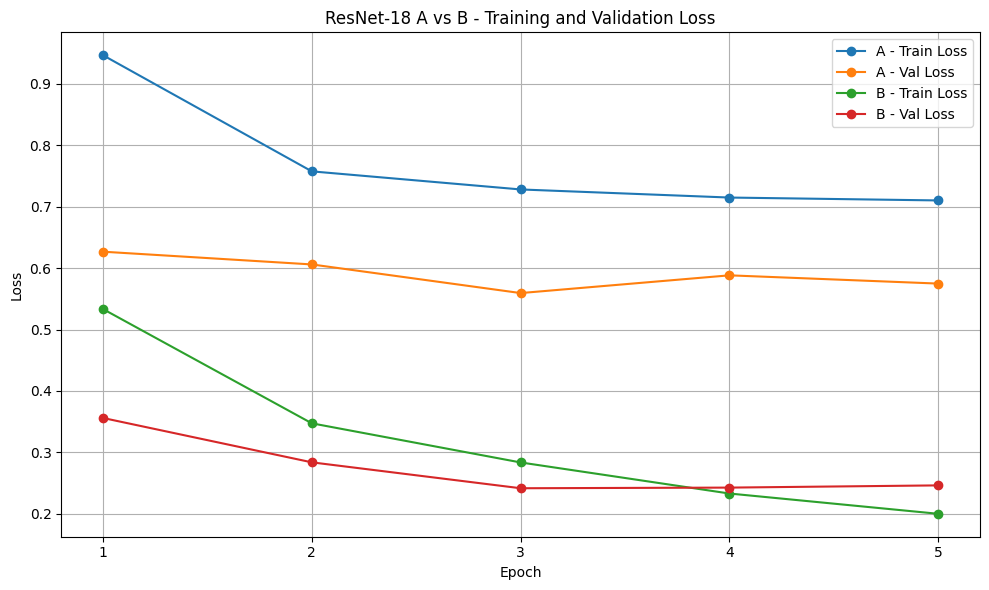

In [27]:
# ============================================================
# CELL 11 - LOSS CURVES
# ============================================================

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history_a["train_loss"],
    marker="o",
    label="A - Train Loss"
)

plt.plot(
    epochs,
    history_a["val_loss"],
    marker="o",
    label="A - Val Loss"
)

plt.plot(
    epochs,
    history_b["train_loss"],
    marker="o",
    label="B - Train Loss"
)

plt.plot(
    epochs,
    history_b["val_loss"],
    marker="o",
    label="B - Val Loss"
)

plt.title("ResNet-18 A vs B - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Accuracy curves

So sánh Train Accuracy và Validation Accuracy của hai chiến lược qua 5 epoch.

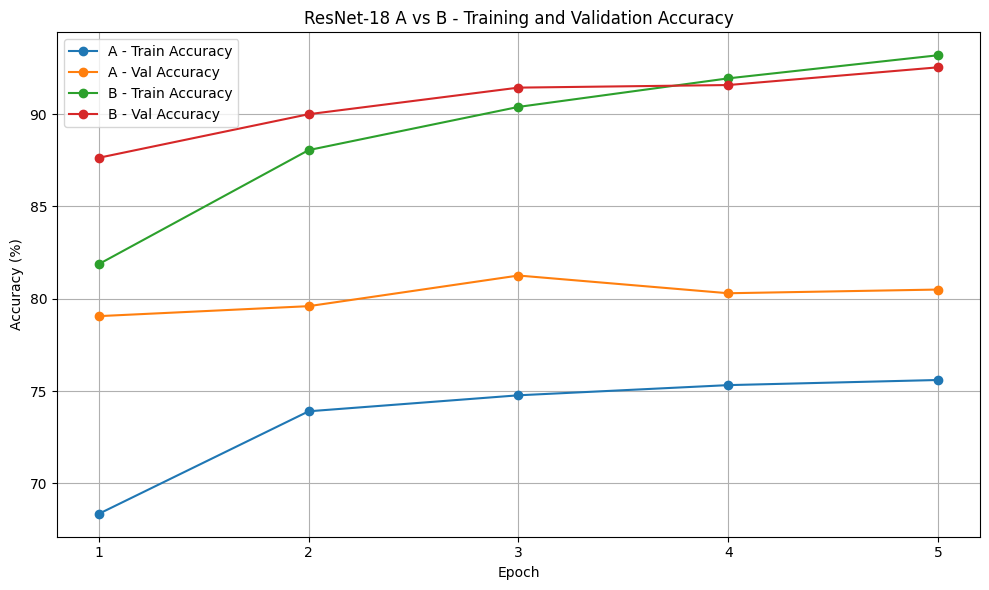

In [28]:
# ============================================================
# CELL 12 - ACCURACY CURVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history_a["train_acc"],
    marker="o",
    label="A - Train Accuracy"
)

plt.plot(
    epochs,
    history_a["val_acc"],
    marker="o",
    label="A - Val Accuracy"
)

plt.plot(
    epochs,
    history_b["train_acc"],
    marker="o",
    label="B - Train Accuracy"
)

plt.plot(
    epochs,
    history_b["val_acc"],
    marker="o",
    label="B - Val Accuracy"
)

plt.title("ResNet-18 A vs B - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(list(epochs))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 13. Checkpoint verification

Kiểm tra các checkpoint tốt nhất của ResNet-18 A và B đã được lưu thành công và có thể load trên thiết bị hiện tại.

In [29]:
# ============================================================
# CELL 13 - CHECKPOINT VERIFICATION
# ============================================================

print("===== CHECKPOINT VERIFICATION =====")

print("\nResNet-18 A:")
print("Path   :", checkpoint_a)
print("Exists :", checkpoint_a.exists())

print("\nResNet-18 B:")
print("Path   :", checkpoint_b)
print("Exists :", checkpoint_b.exists())

# Load checkpoint với device hiện tại
checkpoint_data_a = torch.load(
    checkpoint_a,
    map_location=device
)

checkpoint_data_b = torch.load(
    checkpoint_b,
    map_location=device
)

print("\n===== LOAD CHECK =====")
print("ResNet-18 A checkpoint loaded successfully.")
print("ResNet-18 B checkpoint loaded successfully.")
print("Device :", device)

===== CHECKPOINT VERIFICATION =====

ResNet-18 A:
Path   : /content/UTH-Deep-Learning-nhom2/Practice_2/checkpoints/resnet18_fc_only_best.pth
Exists : True

ResNet-18 B:
Path   : /content/UTH-Deep-Learning-nhom2/Practice_2/checkpoints/resnet18_layer4_fc_best.pth
Exists : True

===== LOAD CHECK =====
ResNet-18 A checkpoint loaded successfully.
ResNet-18 B checkpoint loaded successfully.
Device : cuda


## 14. Kết luận

Hai chiến lược Transfer Learning của ResNet-18 đã được huấn luyện và so sánh trên cùng DataLoader và cùng cấu hình training.

- **ResNet-18 A (FC only):**
  - Trainable parameters: **5,130**
  - Best Validation Accuracy: **81.26%**
  - Best Epoch: **3/5**

- **ResNet-18 B (Layer4 + FC):**
  - Trainable parameters: **8,398,858**
  - Best Validation Accuracy: **92.54%**
  - Best Epoch: **5/5**

ResNet-18 B đạt Validation Accuracy cao hơn ResNet-18 A **11.28 điểm phần trăm**.

Kết quả cho thấy việc fine-tune `layer4 + fc` giúp mô hình thích nghi tốt hơn với CIFAR-10 so với chỉ huấn luyện lớp `fc`. Đổi lại, ResNet-18 B có số lượng tham số cần huấn luyện lớn hơn và yêu cầu nhiều tài nguyên tính toán hơn.

**Kết luận:** Trong hai chiến lược được thử nghiệm, **ResNet-18 B (Layer4 + FC)** cho kết quả tốt hơn.

In [30]:
from google.colab import files

files.download(
    "/content/UTH-Deep-Learning-nhom2/Practice_2/checkpoints/resnet18_fc_only_best.pth"
)

files.download(
    "/content/UTH-Deep-Learning-nhom2/Practice_2/checkpoints/resnet18_layer4_fc_best.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>